<a href="https://colab.research.google.com/github/ErbolTakhirov/Learning-notebooks/blob/main/ML/Bishkek_comp/SGD_BISHKEK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import warnings

from sklearn.linear_model import SGDRegressor

In [2]:
X_just = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/F/expirements/X_just_test_2.csv')
X_just.drop(X_just.columns[0], axis = 1, inplace = True)

In [3]:
X_just.iloc[:, 0]

,square
0,113.80
1,66.00
2,68.00
3,135.00
4,67.00
...,...
7118,48.00
7119,89.00
7120,80.21
7121,145.30


In [4]:
y = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/F/expirements/y.csv')
y.index = y.iloc[:, 0]
y.drop(y.columns[0], axis = 1, inplace = True)
y.index.name = 'index'
y

,usd_price
index,
0,157000
1,96500
2,108500
3,260000
4,103000
...,...
7129,87000
7130,155000
7131,104000


In [5]:
X_just['age'] = 2025 - X_just['age']

<Axes: xlabel='age', ylabel='Count'>

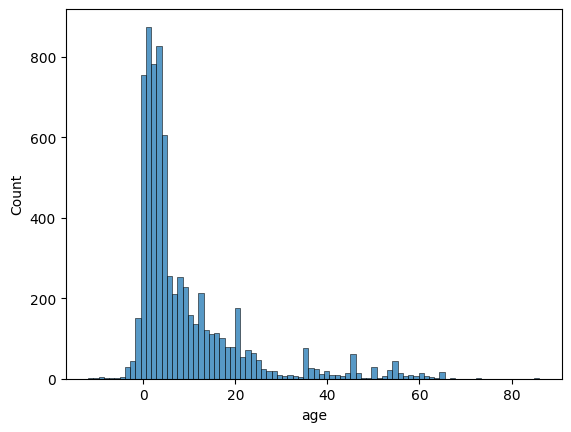

In [6]:
sns.histplot(X_just['age'])

In [7]:
X_just_2 = X_just.copy()
X_just_2.drop('floor_ratio', axis = 1, inplace = True)

In [8]:
X_just_2['floor'] = X_just_2['floor'] + 0.5
X_just_2

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor
0,113.80,1.702601,индивид. планировка,3,кирпичный,8.0,0.370014,8.0,0.666667
1,66.00,7.037787,элитка,2,монолитный,2.0,0.124412,2.0,0.666667
2,68.00,6.519077,106 серия,3,кирпичный,35.0,0.132995,35.0,0.722222
3,135.00,4.643078,элитка,4,монолитный,3.0,0.177208,3.0,0.928571
4,67.00,1.864922,элитка,2,монолитный,2.0,0.349050,2.0,0.928571
...,...,...,...,...,...,...,...,...,...
7118,48.00,1.950375,105 серия,2,панельный,46.0,0.338940,46.0,0.833333
7119,89.00,4.651687,элитка,3,кирпичный,3.0,0.176938,3.0,0.714286
7120,80.21,2.508314,элитка,2,монолитный,0.0,0.285037,0.0,0.676471
7121,145.30,2.794541,индивид. планировка,3,монолитный,6.0,0.263536,6.0,0.500000


In [9]:
X_just_2['series'].value_counts()

,count
series,
элитка,4771
индивид. планировка,959
104 серия,352
105 серия,303
106 серия,249
106 серия улучшенная,130
хрущевка,127
108 серия,90
105 серия улучшенная,37


In [10]:
X_just_2

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor
0,113.80,1.702601,индивид. планировка,3,кирпичный,8.0,0.370014,8.0,0.666667
1,66.00,7.037787,элитка,2,монолитный,2.0,0.124412,2.0,0.666667
2,68.00,6.519077,106 серия,3,кирпичный,35.0,0.132995,35.0,0.722222
3,135.00,4.643078,элитка,4,монолитный,3.0,0.177208,3.0,0.928571
4,67.00,1.864922,элитка,2,монолитный,2.0,0.349050,2.0,0.928571
...,...,...,...,...,...,...,...,...,...
7118,48.00,1.950375,105 серия,2,панельный,46.0,0.338940,46.0,0.833333
7119,89.00,4.651687,элитка,3,кирпичный,3.0,0.176938,3.0,0.714286
7120,80.21,2.508314,элитка,2,монолитный,0.0,0.285037,0.0,0.676471
7121,145.30,2.794541,индивид. планировка,3,монолитный,6.0,0.263536,6.0,0.500000


In [11]:
X_just_2['house_type'].value_counts()

,count
house_type,
монолитный,3844
кирпичный,2186
панельный,1093


In [12]:
from sklearn.model_selection import train_test_split


# Разделяем на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_just_2, y, test_size=0.2, random_state=42, stratify=X_just_2['series']  # стратификация по серии
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")

Train shape: (5698, 9)
Test shape: (1425, 9)


In [18]:
X_train.index = y_train.index

In [19]:
!pip install category_encoders
from category_encoders import TargetEncoder

# Автоматически обрабатывает data leakage
encoder = TargetEncoder(cols=['series'])
X_train_encoded = encoder.fit_transform(X_train, y_train)
X_test_encoded = encoder.transform(X_test)

In [20]:
X_test_encoded

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor
6204,56.0,1.242474,119585.973801,1,монолитный,3.0,0.445936,3.0,0.916667
3960,71.0,1.779492,119585.973801,2,кирпичный,7.0,0.359778,7.0,0.833333
4282,67.0,4.432443,119585.973801,2,кирпичный,1.0,0.184079,1.0,0.900000
4602,107.0,1.188483,119585.973801,3,монолитный,10.0,0.456938,10.0,0.590909
3400,40.0,6.463781,119585.973801,1,монолитный,8.0,0.133980,8.0,0.600000
...,...,...,...,...,...,...,...,...,...
7006,34.0,2.753523,80562.754204,1,панельный,14.0,0.266416,14.0,0.833333
3900,62.0,6.497148,77752.016537,3,кирпичный,22.0,0.133384,22.0,0.900000
6288,89.5,6.796053,119585.973801,2,монолитный,-1.0,0.128270,-1.0,0.750000
5825,52.0,4.405545,119585.973801,2,монолитный,2.0,0.184995,2.0,0.722222


In [21]:
X_train_encoded

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor
index,,,,,,,,,
4845,67.0,8.942062,80562.754204,2,панельный,6.0,0.100583,6.0,0.611111
3524,164.0,4.463549,119585.973801,4,монолитный,5.0,0.183031,5.0,0.966667
4045,83.0,4.044541,119585.973801,3,монолитный,-1.0,0.198234,-1.0,0.916667
1325,44.0,2.295066,117367.250326,2,кирпичный,20.0,0.303484,20.0,0.700000
1927,140.1,2.121862,117367.250326,5,монолитный,6.0,0.320322,6.0,0.966667
...,...,...,...,...,...,...,...,...,...
4007,60.0,2.659364,76308.322695,3,панельный,24.0,0.273271,24.0,0.500000
4782,78.0,3.583580,119585.973801,2,монолитный,0.0,0.218170,0.0,0.794118
2591,128.0,2.067574,119585.973801,3,монолитный,4.0,0.325991,4.0,0.785714


In [22]:
encoder_house = TargetEncoder(cols=['house_type'])
X_train['house_type_encoded'] = encoder_house.fit_transform(X_train[['house_type']], y_train)['house_type']
X_test['house_type_encoded'] = encoder_house.transform(X_test[['house_type']])['house_type']

In [23]:
X_train_encoded.dtypes

,0
square,float64
distance_am,float64
series,float64
rooms,int64
house_type,object
year,float64
inv_distance,float64
age,float64
floor,float64


In [24]:
# Посмотрим на текущие данные
print("Типы данных:")
print(X_train_encoded.dtypes)

print("\nУникальные значения series:")
print(X_train_encoded['series'].unique()[:10])  # первые 10 значений

print("\nУникальные значения house_type:")
print(X_train_encoded['house_type'].unique())

print("\nСтатистика по series:")
print(X_train_encoded['series'].describe())


Типы данных:
square          float64
distance_am     float64
series          float64
rooms             int64
house_type       object
year            float64
inv_distance    float64
age             float64
floor           float64
dtype: object

Уникальные значения series:
[ 80562.75420427 119585.97380141 117367.25032595  89008.03556377
  78503.42561159  76308.32269518  60938.36234717  98675.43733199
  79272.50396176  77752.01653676]

Уникальные значения house_type:
['панельный' 'монолитный' 'кирпичный']

Статистика по series:
count      5698.000000
mean     111765.497589
std       17990.034767
min       58220.599630
25%      117367.250326
50%      119585.973801
75%      119585.973801
max      246330.403454
Name: series, dtype: float64


In [25]:
from category_encoders import TargetEncoder

# Просто кодируем house_type и оставляем остальные фичи как есть
house_encoder = TargetEncoder(cols=['house_type'])

X_train_final = house_encoder.fit_transform(X_train, y_train)
X_test_final = house_encoder.transform(X_test)

# Удаляем оригинальный house_type если он остался как объект
if 'house_type' in X_train_final.columns and X_train_final['house_type'].dtype == 'object':
    X_train_final = X_train_final.drop('house_type', axis=1)
    X_test_final = X_test_final.drop('house_type', axis=1)

print("Готово!")
print(f"X_train_final shape: {X_train_final.shape}")
print(f"X_test_final shape: {X_test_final.shape}")
print(f"Столбцы: {X_train_final.columns.tolist()}")

Готово!
X_train_final shape: (5698, 10)
X_test_final shape: (1425, 10)
Столбцы: ['square', 'distance_am', 'series', 'rooms', 'house_type', 'year', 'inv_distance', 'age', 'floor', 'house_type_encoded']


In [53]:
X_train_final

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor,house_type_encoded
index,,,,,,,,,,
4845,67.0,8.942062,106 серия улучшенная,2,82811.482679,6.0,0.100583,6.0,0.611111,82811.482679
3524,164.0,4.463549,элитка,4,121082.555160,5.0,0.183031,5.0,0.966667,121082.555160
4045,83.0,4.044541,элитка,3,121082.555160,-1.0,0.198234,-1.0,0.916667,121082.555160
1325,44.0,2.295066,индивид. планировка,2,110566.957496,20.0,0.303484,20.0,0.700000,110566.957496
1927,140.1,2.121862,индивид. планировка,5,121082.555160,6.0,0.320322,6.0,0.966667,121082.555160
...,...,...,...,...,...,...,...,...,...,...
4007,60.0,2.659364,104 серия,3,82811.482679,24.0,0.273271,24.0,0.500000,82811.482679
4782,78.0,3.583580,элитка,2,121082.555160,0.0,0.218170,0.0,0.794118,121082.555160
2591,128.0,2.067574,элитка,3,121082.555160,4.0,0.325991,4.0,0.785714,121082.555160


In [56]:
X_train_final.drop('series', axis = 1, inplace = True)

In [41]:
X_just_2

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor
0,113.80,1.702601,индивид. планировка,3,кирпичный,8.0,0.370014,8.0,0.666667
1,66.00,7.037787,элитка,2,монолитный,2.0,0.124412,2.0,0.666667
2,68.00,6.519077,106 серия,3,кирпичный,35.0,0.132995,35.0,0.722222
3,135.00,4.643078,элитка,4,монолитный,3.0,0.177208,3.0,0.928571
4,67.00,1.864922,элитка,2,монолитный,2.0,0.349050,2.0,0.928571
...,...,...,...,...,...,...,...,...,...
7129,48.00,1.950375,105 серия,2,панельный,46.0,0.338940,46.0,0.833333
7130,89.00,4.651687,элитка,3,кирпичный,3.0,0.176938,3.0,0.714286
7131,80.21,2.508314,элитка,2,монолитный,0.0,0.285037,0.0,0.676471
7132,145.30,2.794541,индивид. планировка,3,монолитный,6.0,0.263536,6.0,0.500000


In [44]:
X_just_2.reset_index(drop= True)

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor
0,113.80,1.702601,индивид. планировка,3,кирпичный,8.0,0.370014,8.0,0.666667
1,66.00,7.037787,элитка,2,монолитный,2.0,0.124412,2.0,0.666667
2,68.00,6.519077,106 серия,3,кирпичный,35.0,0.132995,35.0,0.722222
3,135.00,4.643078,элитка,4,монолитный,3.0,0.177208,3.0,0.928571
4,67.00,1.864922,элитка,2,монолитный,2.0,0.349050,2.0,0.928571
...,...,...,...,...,...,...,...,...,...
7118,48.00,1.950375,105 серия,2,панельный,46.0,0.338940,46.0,0.833333
7119,89.00,4.651687,элитка,3,кирпичный,3.0,0.176938,3.0,0.714286
7120,80.21,2.508314,элитка,2,монолитный,0.0,0.285037,0.0,0.676471
7121,145.30,2.794541,индивид. планировка,3,монолитный,6.0,0.263536,6.0,0.500000


In [49]:
total = 0
for i in X_train_final.index:
  if i in X_test_final.index:
    total += 1
print(total)

1014


In [45]:
X_just_2.index = np.sort(np.concatenate([X_train_final.index, X_test_final.index]))

In [47]:
X_just_2.loc[X_just_2.index.duplicated()]

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor
926,77.0,3.359687,элитка,2,монолитный,0.0,0.229374,0.0,0.785714
929,106.0,4.457857,элитка,3,монолитный,4.0,0.183222,4.0,0.916667
931,43.0,2.787290,элитка,1,монолитный,10.0,0.264041,10.0,0.833333
936,174.0,5.497136,индивид. планировка,4,монолитный,0.0,0.153914,0.0,1.000000
945,84.0,2.406612,индивид. планировка,2,кирпичный,6.0,0.293547,6.0,0.916667
...,...,...,...,...,...,...,...,...,...
7098,90.0,3.479395,108 серия,3,монолитный,3.0,0.223244,3.0,0.722222
7100,45.0,3.031616,104 серия,2,панельный,19.0,0.248039,19.0,1.000000
7112,100.0,2.787290,элитка,3,монолитный,2.0,0.264041,2.0,0.583333
7113,100.0,4.891459,элитка,3,монолитный,3.0,0.169737,3.0,0.700000


In [46]:
X_train_final['series'] = X_just_2.series[X_train_final.index]
X_test_final['series'] = X_just_2.series[X_test_final.index]

ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
# from sklearn.model_selection import GridSearchCV
# from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from sklearn.tree import DecisionTreeRegressor
# from sklearn.neighbors import KNeighborsRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# import numpy as np

# # 1. Линейная регрессия
# print("Настраиваем Linear Regression...")
# lr = LinearRegression()
# lr.fit(X_train_final, y_train)
# y_pred_lr = lr.predict(X_test_final)
# print(f"Linear Regression MAE: {mean_absolute_error(y_test, y_pred_lr):.2f}")

# # 2. Ridge регрессия с GridSearch
# print("\nНастраиваем Ridge Regression...")
# ridge = Ridge()
# ridge_params = {
#     'alpha': [0.01, 0.1, 1.0, 10.0, 100.0],
#     'max_iter': [1000, 2000]
# }

# ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
# ridge_grid.fit(X_train_final, y_train)

# print(f"Лучшие параметры Ridge: {ridge_grid.best_params_}")
# print(f"Лучший MAE Ridge: {-ridge_grid.best_score_:.2f}")

# # 3. Lasso регрессия с GridSearch
# print("\nНастраиваем Lasso Regression...")
# lasso = Lasso()
# lasso_params = {
#     'alpha': [0.001, 0.01, 0.1, 1.0],
#     'max_iter': [1000, 2000]
# }

# lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
# lasso_grid.fit(X_train_final, y_train)

# print(f"Лучшие параметры Lasso: {lasso_grid.best_params_}")
# print(f"Лучший MAE Lasso: {-lasso_grid.best_score_:.2f}")

# # 4. Decision Tree с GridSearch
# print("\nНастраиваем Decision Tree...")
# tree = DecisionTreeRegressor(random_state=42)
# tree_params = {
#     'max_depth': [3, 5, 7, 10, None],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# tree_grid = GridSearchCV(tree, tree_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
# tree_grid.fit(X_train_final, y_train)

# print(f"Лучшие параметры Decision Tree: {tree_grid.best_params_}")
# print(f"Лучший MAE Decision Tree: {-tree_grid.best_score_:.2f}")

# # 5. K-Neighbors с GridSearch
# print("\nНастраиваем K-Neighbors...")
# knn = KNeighborsRegressor()
# knn_params = {
#     'n_neighbors': [3, 5, 7, 9, 11],
#     'weights': ['uniform', 'distance']
# }

# knn_grid = GridSearchCV(knn, knn_params, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
# knn_grid.fit(X_train_final, y_train)

# print(f"Лучшие параметры KNN: {knn_grid.best_params_}")
# print(f"Лучший MAE KNN: {-knn_grid.best_score_:.2f}")

In [50]:
X_train_encoded['series']

,series
index,
4845,80562.754204
3524,119585.973801
4045,119585.973801
1325,117367.250326
1927,117367.250326
...,...
4007,76308.322695
4782,119585.973801
2591,119585.973801


In [51]:
X_just_2['series'] = X_just_2.merge(X_train_encoded.series, how = 'left', right_index = True, left_index = True).series_y.fillna(X_test_encoded.series)
# X_just_2.drop(['series_x', 'series_y'], axis = 1, inplace = True)
X_just_2

,square,distance_am,series,rooms,house_type,year,inv_distance,age,floor
0,113.80,1.702601,117367.250326,3,кирпичный,8.0,0.370014,8.0,0.666667
1,66.00,7.037787,119585.973801,2,монолитный,2.0,0.124412,2.0,0.666667
2,68.00,6.519077,89008.035564,3,кирпичный,35.0,0.132995,35.0,0.722222
3,135.00,4.643078,119585.973801,4,монолитный,3.0,0.177208,3.0,0.928571
4,67.00,1.864922,119585.973801,2,монолитный,2.0,0.349050,2.0,0.928571
...,...,...,...,...,...,...,...,...,...
7129,48.00,1.950375,77752.016537,2,панельный,46.0,0.338940,46.0,0.833333
7130,89.00,4.651687,119585.973801,3,кирпичный,3.0,0.176938,3.0,0.714286
7131,80.21,2.508314,119585.973801,2,монолитный,0.0,0.285037,0.0,0.676471
7132,145.30,2.794541,117367.250326,3,монолитный,6.0,0.263536,6.0,0.500000


In [57]:
y_train

,usd_price
index,
4845,80000
3524,393600
4045,73040
1325,71500
1927,350000
...,...
4007,88000
4782,96500
2591,235000


In [58]:
model = SGDRegressor(loss='huber')
param_grid = {'penalty': ['l2', 'l1'],
              'alpha': np.logspace(-2, 3, 15),
              'eta0': [.05, .15],
              'power_t': [.3, .1],
               'epsilon': [200, 400]}

searcher = GridSearchCV(model, param_grid, scoring="neg_root_mean_squared_error", cv=4, verbose=3, n_jobs=5)
searcher.fit(X_train_final, y_train)

Fitting 4 folds for each of 240 candidates, totalling 960 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GridSearchCV(cv=4, estimator=SGDRegressor(loss='huber'), n_jobs=5,
             param_grid={'alpha': array([1.00000000e-02, 2.27584593e-02, 5.17947468e-02, 1.17876863e-01,
       2.68269580e-01, 6.10540230e-01, 1.38949549e+00, 3.16227766e+00,
       7.19685673e+00, 1.63789371e+01, 3.72759372e+01, 8.48342898e+01,
       1.93069773e+02, 4.39397056e+02, 1.00000000e+03]),
                         'epsilon': [200, 400], 'eta0': [0.05, 0.15],
                         'penalty': ['l2', 'l1'], 'power_t': [0.3, 0.1]},
             scoring='neg_root_mean_squared_error', verbose=3)

In [ ]:
X_just_2['house_type'] = pd.concat([X_train_final['house_type'], X_test_final['house_type']])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_just_2, y, test_size=.25)

SGD = SGDRegressor(
    loss='huber',
    alpha=searcher.best_params_['alpha'],
    epsilon=searcher.best_params_['epsilon'],
    eta0=searcher.best_params_['eta0'],
    penalty=searcher.best_params_['penalty'],
    power_t=searcher.best_params_['power_t']
)

model = Pipeline([
    ('regressor', SGD)
])

In [ ]:
X_train.columns, X_test.columns

In [ ]:
model.fit(X_train, np.log(y_train))
y_train_pred = model.predict(X_train)
y_pred = np.exp(model.predict(X_test))

In [ ]:
print("TEST R2:\t %.4f" % r2_score(y_test, y_pred))
print("TEST MAPE:\t %.4f" % mean_absolute_percentage_error(y_test, y_pred))
print('-----------------')
# print("TEST RMSE:\t %.4f" % mean_squared_error(y_test, y_pred, squared=False))
print("TEST MAE:\t %.4f" % mean_absolute_error(y_test, y_pred))

In [ ]:
y